### **Bài tập chương 3**


**Câu 1: Hãy viết câu lệnh SQL để tính sự tương quan giữa A và B theo công thức sau:**
$$
r_{AB} = \frac{n \sum (a_i b_i) - \sum a_i \sum b_i}{\sqrt{n \sum a_i^2 - (\sum a_i)^2} \cdot \sqrt{n \sum b_i^2 - (\sum b_i)^2}}
$$


In [6]:
import sqlite3
import math

# Kết nối tới cơ sở dữ liệu SQLite (nếu chưa có, sẽ tạo mới)
conn = sqlite3.connect('correlation.db')
cursor = conn.cursor()

# Tạo bảng để lưu dữ liệu A và B
cursor.execute('''
    CREATE TABLE IF NOT EXISTS data (
        a FLOAT,
        b FLOAT
    )
''')

# Thêm dữ liệu mẫu (các cặp giá trị a_i, b_i)
data = [
    (1.0, 2.0),
    (2.0, 4.0),
    (3.0, 6.0),
    (4.0, 8.0),
    (5.0, 10.0)
]

cursor.executemany('INSERT INTO data (a, b) VALUES (?, ?)', data)
conn.commit()

In [7]:
# Kết nối tới cơ sở dữ liệu SQLite
conn = sqlite3.connect('correlation.db')
cursor = conn.cursor()
#công thức 
cursor.execute('''
    SELECT 
        (COUNT(*) * SUM(a * b) - SUM(a) * SUM(b)) / 
        (SQRT(COUNT(*) * SUM(a * a) - SUM(a) * SUM(a)) * 
         SQRT(COUNT(*) * SUM(b * b) - SUM(b) * SUM(b))) AS r_AB
    FROM data
''')

# Lấy kết quả
r_AB = cursor.fetchone()[0]

# In kết quả
if r_AB is not None:
    print(f"Hệ số tương quan r_AB: {r_AB}")
else:
    print("Không thể tính hệ số tương quan (có thể do mẫu số bằng 0 hoặc không có dữ liệu).")

# Đóng kết nối
conn.close()

Hệ số tương quan r_AB: 0.9999999999999999


**Câu 2: Một công ty ô tô đang kiểm tra 3 loại mẫu mới A, B và C trong 4 ngày, và chấm điểm theo thang từ 1 đến 10 điểm cho mỗi ngày với bảng sau:Liệu có sự khác biệt đáng kể giữa các mẫu dựa trên điểm số mà chúng nhận được trong 4 ngày thử nghiệm không?  Kết quả thử nghiệm phụ thuộc vào ngày hay phụ thuộc vào mẫu xe? Hãy chuyển đổi dữ liệu sang dạng quan hệ và thực hiện kiểm tra 𝜒² (Chi-squared test).**
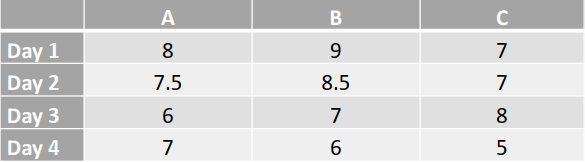


In [1]:
import sqlite3
import pandas as pd
import scipy.stats as stats

# Kết nối SQLite
conn = sqlite3.connect("correlation.db")
cursor = conn.cursor()


# Tạo bảng dạng quan hệ
cursor.execute('''
    CREATE TABLE car_scores (
        day VARCHAR,
        model VARCHAR,
        score FLOAT
    )
''')

# Dữ liệu mẫu
data = [
    ("Day 1", "A", 8), ("Day 1", "B", 9), ("Day 1", "C", 7),
    ("Day 2", "A", 7.5), ("Day 2", "B", 8.5), ("Day 2", "C", 7),
    ("Day 3", "A", 6), ("Day 3", "B", 7), ("Day 3", "C", 8),
    ("Day 4", "A", 7), ("Day 4", "B", 6), ("Day 4", "C", 5)
]

# Chèn dữ liệu
cursor.executemany("INSERT INTO car_scores (day, model, score) VALUES (?, ?, ?)", data)
conn.commit()
# Truy vấn điểm theo từng mẫu xe
query_anova = '''
SELECT model, score FROM car_scores
'''
df = pd.read_sql_query(query_anova, conn)

scores_by_model = df.groupby('model')['score'].apply(list)
f_stat, p_value = stats.f_oneway(*scores_by_model)

print("One-Way ANOVA giữa các mẫu xe")
print("F-statistic:", f_stat)
print("p-value:", p_value)
if p_value < 0.05:
    print("Có sự khác biệt đáng kể giữa các mẫu xe.\n")
else:
    print("Không có sự khác biệt đáng kể giữa các mẫu xe.\n")

One-Way ANOVA giữa các mẫu xe
F-statistic: 0.5495049504950494
p-value: 0.5954382115847785
Không có sự khác biệt đáng kể giữa các mẫu xe.



In [2]:
from scipy.stats import chi2_contingency
# Thêm cột score_group
cursor.execute('''
    ALTER TABLE car_scores ADD COLUMN score_group TEXT
''')

# Gán mức điểm: Low (<=6), Medium (6 < score <= 8), High (>8)
cursor.execute('''
    UPDATE car_scores
    SET score_group = 
        CASE
            WHEN score <= 6 THEN 'Low'
            WHEN score <= 8 THEN 'Medium'
            ELSE 'High'
        END
''')
conn.commit()

# Lấy dữ liệu
df = pd.read_sql_query("SELECT * FROM car_scores", conn)

# Tạo bảng tần suất (Contingency Table): Day x Score Group
contingency_table = pd.pivot_table(
    df, 
    values="score", 
    index="day", 
    columns="score_group", 
    aggfunc="count", 
    fill_value=0
)

print("Bảng tần suất giữa Ngày và Nhóm điểm:")
print(contingency_table)

# Thực hiện kiểm định Chi-Square
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\n Chi-Square Test")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"Bậc tự do: {dof}")
print("Giá trị kỳ vọng:")
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns))

# Đóng kết nối
cursor.close()
conn.close()


Bảng tần suất giữa Ngày và Nhóm điểm:
score_group  High  Low  Medium
day                           
Day 1           1    0       2
Day 2           1    0       2
Day 3           0    1       2
Day 4           0    2       1

 Chi-Square Test
Chi-square statistic: 6.0952
p-value: 0.4126
Bậc tự do: 6
Giá trị kỳ vọng:
score_group  High   Low  Medium
day                            
Day 1         0.5  0.75    1.75
Day 2         0.5  0.75    1.75
Day 3         0.5  0.75    1.75
Day 4         0.5  0.75    1.75


**Câu 3: Bảng flights(departure_time,…) chứa các giá trị thời gian dưới dạng số nguyên (ví dụ: 830 cho 8:30
AM, 1445 cho 2:45 PM). Hãy chuyển đổi các giá trị này thành định dạng thời gian**

In [5]:
import sqlite3

# Kết nối đến cơ sở dữ liệu
conn = sqlite3.connect('correlation.db')
cursor = conn.cursor()

# Tạo bảng và chèn dữ liệu mẫu
cursor.execute('''CREATE TABLE IF NOT EXISTS flights 
                  (id_time INTEGER PRIMARY KEY, departure_time INTEGER)''')
cursor.executemany('INSERT OR IGNORE INTO flights (id_time, departure_time) VALUES (?, ?)',
                   [(1, 830), (2, 1445), (3, 30), (4, 1200),(5,1650),(6,730)])
conn.commit()

# Truy vấn để định dạng thời gian
cursor.execute("""
    SELECT 
        id_time,
        departure_time,
        printf('%02d:%02d %s', 
            (departure_time / 100 + 11) % 12 + 1, 
            departure_time % 100, 
            CASE WHEN departure_time / 100 >= 12 THEN 'PM' ELSE 'AM' END
        ) AS formatted_time
    FROM flights
""")
rows = cursor.fetchall()

# Hiển thị kết quả
for row in rows:
    id_time, departure_time, formatted_time = row
    # Bỏ số 0 ở đầu giờ
    formatted_time_no_zero = formatted_time.lstrip('0')
    print((id_time, departure_time, formatted_time_no_zero))
# Đóng kết nối
conn.close()

(1, 830, '8:30 AM')
(2, 1445, '2:45 PM')
(3, 30, '12:30 AM')
(4, 1200, '12:00 PM')
(5, 1650, '4:50 PM')
(6, 730, '7:30 AM')


**Câu 4: Viết truy vấn SQL để tìm các ngoại lệ bằng cách sử dụng MAD. Một quy tắc chung là xem xét các giá
trị ngoại lệ lớn hơn 1,5 lần so với giá trị MAD, trong đó x là số độ lệch chuẩn mà ta coi là có ý nghĩa.**

In [20]:
import sqlite3

# Kết nối database
conn = sqlite3.connect('correlation.db')
cursor = conn.cursor()

# Xóa bảng cũ nếu tồn tại, rồi tạo mới và chèn dữ liệu
cursor.execute('DROP TABLE IF EXISTS scores')
cursor.execute('CREATE TABLE scores (id INTEGER PRIMARY KEY AUTOINCREMENT, score REAL)')
data = [(18.5,), (19.2,), (19.8,), (20.1,), (20.5,), (21.0,), (19.5,), (20.3,), (17.8,), (22.0,), (100.0,), (-50.0,)]
cursor.executemany('INSERT INTO scores (score) VALUES (?)', data)
conn.commit()

#Tính median
cursor.execute("SELECT AVG(score) FROM (SELECT score FROM scores ORDER BY score LIMIT 2 OFFSET (SELECT (COUNT(*) - 1) / 2 FROM scores))")
median = cursor.fetchone()[0]
print(f"Median: {median:.2f}")

#Tính độ lệch tuyệt đối
cursor.execute(f"SELECT id, score, ABS(score - {median}) FROM scores")
print("\nĐộ lệch tuyệt đối:")
for row in cursor.fetchall():
    print(f"ID: {row[0]} | Score: {row[1]} | Độ lệch: {round(row[2], 2)}")

#Tính MAD (median của các độ lệch tuyệt đối)
cursor.execute(f"SELECT AVG(abs_dev) FROM (SELECT ABS(score - {median}) AS abs_dev FROM scores ORDER BY abs_dev LIMIT 2 OFFSET (SELECT (COUNT(*) - 1) / 2 FROM scores))")
mad = cursor.fetchone()[0]
print(f"\nMAD: {mad:.2f}")

#Tính ngưỡng
threshold = mad * 1.5
print(f"Ngưỡng (1.5 * MAD): {threshold:.2f}")

#Tìm ngoại lệ
cursor.execute(f"SELECT id, score FROM scores WHERE ABS(score - {median}) > {threshold} ORDER BY score")
print("\nBước 5 - Các giá trị ngoại lệ:")
for row in cursor.fetchall():
    print(f"ID: {row[0]} | Score: {row[1]}")

conn.close()

Median: 19.95

Độ lệch tuyệt đối:
ID: 1 | Score: 18.5 | Độ lệch: 1.45
ID: 2 | Score: 19.2 | Độ lệch: 0.75
ID: 3 | Score: 19.8 | Độ lệch: 0.15
ID: 4 | Score: 20.1 | Độ lệch: 0.15
ID: 5 | Score: 20.5 | Độ lệch: 0.55
ID: 6 | Score: 21.0 | Độ lệch: 1.05
ID: 7 | Score: 19.5 | Độ lệch: 0.45
ID: 8 | Score: 20.3 | Độ lệch: 0.35
ID: 9 | Score: 17.8 | Độ lệch: 2.15
ID: 10 | Score: 22.0 | Độ lệch: 2.05
ID: 11 | Score: 100.0 | Độ lệch: 80.05
ID: 12 | Score: -50.0 | Độ lệch: 69.95

MAD: 0.90
Ngưỡng (1.5 * MAD): 1.35

Bước 5 - Các giá trị ngoại lệ:
ID: 12 | Score: -50.0
ID: 9 | Score: 17.8
ID: 1 | Score: 18.5
ID: 10 | Score: 22.0
ID: 11 | Score: 100.0


**Câu 5: Hãy xác định liệu hai người trong bảng Patient(last_name, weight, height) có phải là một người hay
không bằng cách sử dụng khoảng cách kết hợp Boolean trên “last_name” và “weight”.**

In [22]:
import sqlite3

# Kết nối database
conn = sqlite3.connect('correlation.db')
cursor = conn.cursor()

# Xóa bảng cũ khi đã tồn tại, ,tạo bảng mới
cursor.execute('DROP TABLE IF EXISTS Patient')
cursor.execute('CREATE TABLE Patient (id INTEGER PRIMARY KEY AUTOINCREMENT, last_name TEXT, weight REAL, height REAL)')

#dữ liệu mẫu
data = [
    ('Nguyen', 70.5, 1.75),
    ('Nguyen', 70.5, 1.65), 
    ('Tran', 65.0, 1.70),
    ('Nguyen', 80.0, 1.80),  
    ('Le', 70.5, 1.60),      
]
cursor.executemany('INSERT INTO Patient (last_name, weight, height) VALUES (?, ?, ?)', data)
conn.commit()

# Truy vấn để so sánh từng cặp bản ghi
query = """
SELECT 
    p1.id AS id1, 
    p1.last_name AS name1, 
    p1.weight AS weight1,
    p2.id AS id2, 
    p2.last_name AS name2, 
    p2.weight AS weight2,
    CASE WHEN p1.last_name = p2.last_name THEN 1 ELSE 0 END AS name_match,
    CASE WHEN p1.weight = p2.weight THEN 1 ELSE 0 END AS weight_match
FROM Patient p1
JOIN Patient p2 
    ON p1.id < p2.id
"""
cursor.execute(query)

# In kết quả và xác định
print("So sánh các cặp bản ghi trong bảng Patient:")
print(f"{'ID1':<4} {'Name1':<8} {'Weight1':<8} {'ID2':<4} {'Name2':<8} {'Weight2':<8} {'Name Match':<12} {'Weight Match':<12} {'Cùng 1 người?':<12}")
for row in cursor.fetchall():
    id1, name1, weight1, id2, name2, weight2, name_match, weight_match = row
    is_same_person = "Có" if name_match == 1 and weight_match == 1 else "Không"
    print(f"{id1:<4} {name1:<8} {weight1:<8.1f} {id2:<4} {name2:<8} {weight2:<8.1f} {name_match:<12} {weight_match:<12} {is_same_person:<12}")

conn.close()

So sánh các cặp bản ghi trong bảng Patient:
ID1  Name1    Weight1  ID2  Name2    Weight2  Name Match   Weight Match Cùng 1 người?
1    Nguyen   70.5     2    Nguyen   70.5     1            1            Có          
1    Nguyen   70.5     3    Tran     65.0     0            0            Không       
1    Nguyen   70.5     4    Nguyen   80.0     1            0            Không       
1    Nguyen   70.5     5    Le       70.5     0            1            Không       
2    Nguyen   70.5     3    Tran     65.0     0            0            Không       
2    Nguyen   70.5     4    Nguyen   80.0     1            0            Không       
2    Nguyen   70.5     5    Le       70.5     0            1            Không       
3    Tran     65.0     4    Nguyen   80.0     0            0            Không       
3    Tran     65.0     5    Le       70.5     0            0            Không       
4    Nguyen   80.0     5    Le       70.5     0            0            Không       


Bảng kết qua cho thấy có 1 cặp được xá định là cùng một người: (1,Nguyen,70.5) và  (2,    Nguyen ,  70.5 ) khi có cùng số weight